<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Proyecto2/CargaCampo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

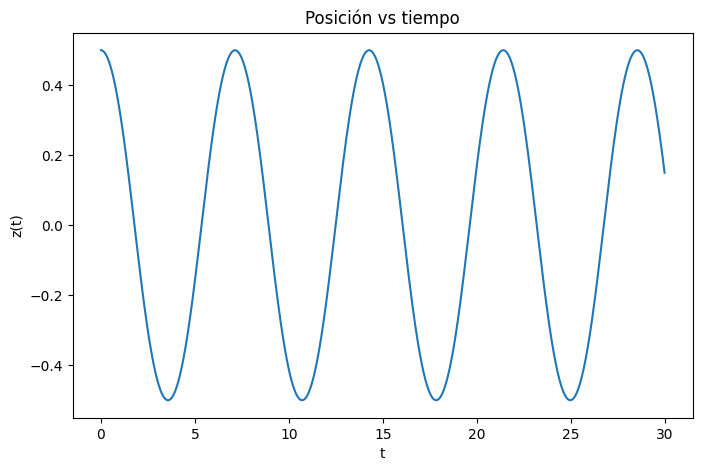

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

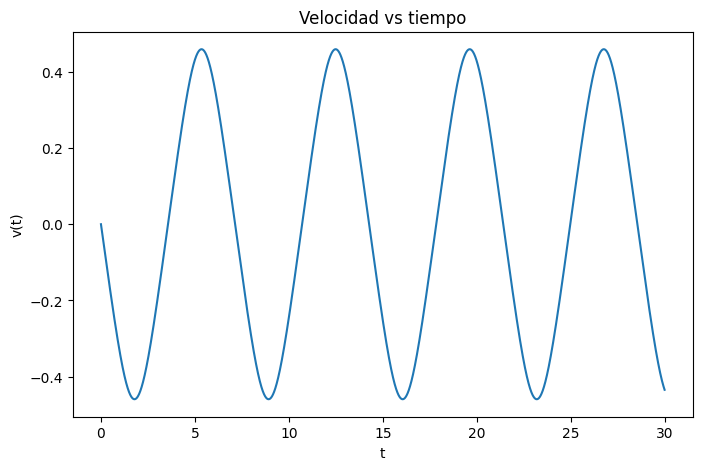

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

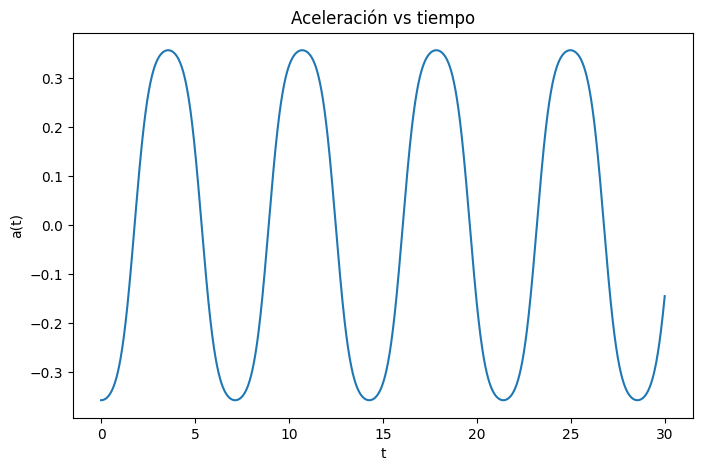

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

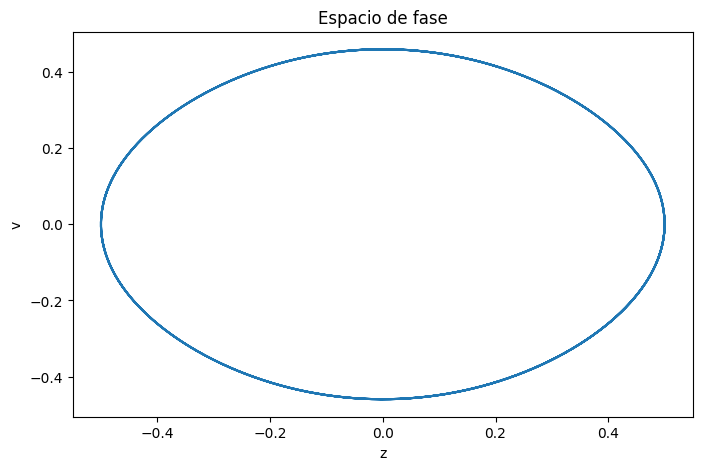

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

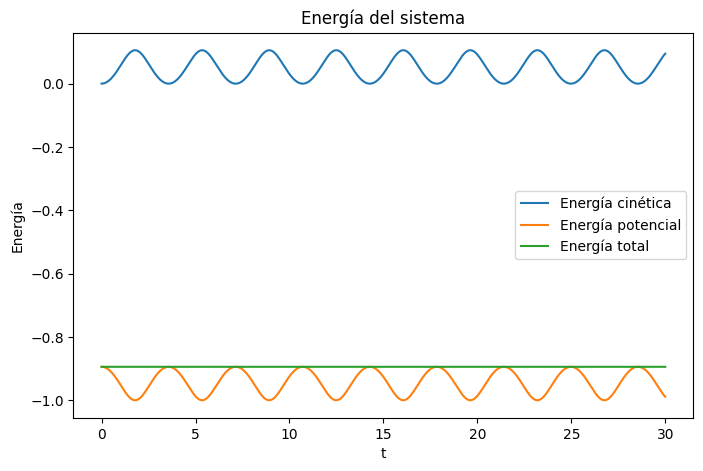

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Periodo aproximado: 7.1369
Frecuencia aproximada: 0.1401


In [4]:
# =====================================================
# PROYECTO 2: CARGA EN CAMPO DE UN ANILLO
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================================================
# PARAMETROS FISICOS (UNIDADES NORMALIZADAS)
# =====================================================

q = -1.0      # carga de prueba (negativa)
Q = 1.0       # carga del anillo
m = 1.0       # masa
R = 1.0       # radio del anillo
k = 1.0       # constante efectiva > 0

# =====================================================
# TIEMPO
# =====================================================

dt = 0.001
t_max = 30
t = np.arange(0, t_max, dt)

# =====================================================
# VARIABLES
# =====================================================

z = np.zeros(len(t))
v = np.zeros(len(t))
a = np.zeros(len(t))

# condiciones iniciales
z[0] = 0.5
v[0] = 0.0

# =====================================================
# DINAMICA (METODO DE EULER SEMI-IMPLICITO)
# =====================================================

for i in range(len(t)-1):

    # aceleracion restauradora correcta
    a[i] = -k * z[i] / ((z[i]**2 + R**2)**(3/2))

    # Euler semi-implícito
    v[i+1] = v[i] + a[i]*dt
    z[i+1] = z[i] + v[i+1]*dt

# ultimo valor de aceleracion
a[-1] = -k * z[-1] / ((z[-1]**2 + R**2)**(3/2))

# =====================================================
# ENERGIA DEL SISTEMA
# =====================================================

# Energía cinética
K = 0.5 * m * v**2

# Energía potencial
U = -k / np.sqrt(z**2 + R**2)

# Energía total
E = K + U

# =====================================================
# GRAFICA 1: POSICION
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(t, z)
plt.xlabel("t")
plt.ylabel("z(t)")
plt.title("Posición vs tiempo")

plt.savefig("Proyecto2_z_t.pdf", dpi=300, bbox_inches="tight")
plt.show()
files.download("Proyecto2_z_t.pdf")

# =====================================================
# GRAFICA 2: VELOCIDAD
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(t, v)
plt.xlabel("t")
plt.ylabel("v(t)")
plt.title("Velocidad vs tiempo")

plt.savefig("Proyecto2_v_t.pdf", dpi=300, bbox_inches="tight")
plt.show()
files.download("Proyecto2_v_t.pdf")

# =====================================================
# GRAFICA 3: ACELERACION
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(t, a)
plt.xlabel("t")
plt.ylabel("a(t)")
plt.title("Aceleración vs tiempo")

plt.savefig("Proyecto2_a_t.pdf", dpi=300, bbox_inches="tight")
plt.show()
files.download("Proyecto2_a_t.pdf")

# =====================================================
# GRAFICA 4: ESPACIO DE FASE
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(z, v)
plt.xlabel("z")
plt.ylabel("v")
plt.title("Espacio de fase")

plt.savefig("Proyecto2_fase.pdf", dpi=300, bbox_inches="tight")
plt.show()
files.download("Proyecto2_fase.pdf")

# =====================================================
# GRAFICA 5: ENERGIA
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(t, K, label="Energía cinética")
plt.plot(t, U, label="Energía potencial")
plt.plot(t, E, label="Energía total")

plt.xlabel("t")
plt.ylabel("Energía")
plt.legend()
plt.title("Energía del sistema")

plt.savefig("Proyecto2_energia.pdf", dpi=300, bbox_inches="tight")
plt.show()
files.download("Proyecto2_energia.pdf")

# =====================================================
# ESTIMACION DEL PERIODO
# =====================================================

indices = np.where(np.diff(np.sign(z)))[0]

if len(indices) > 2:
    tiempos_cruce = t[indices]
    periodos = 2 * np.diff(tiempos_cruce)
    T_prom = np.mean(periodos)
    f = 1 / T_prom

    print(f"Periodo aproximado: {T_prom:.4f}")
    print(f"Frecuencia aproximada: {f:.4f}")
else:
    print("No se pudo estimar el periodo")